# Advanced Fraud Detection: EDA, Concept Drift, and Preprocessing

### Project Context: Digital Banking Security and SDG 16
Fraudulent activities in digital banking pose a significant threat to the stability of financial systems. This project aligns with **Sustainable Development Goal 16 (Peace, Justice, and Strong Institutions)**. By developing adaptive AI models that can detect evolving fraud patterns, we help build effective, accountable, and transparent institutions.

**The Challenge:** Criminal behavior is not static; it exhibits **Concept Drift**, where the statistical properties of the target variable change over time. This notebook focuses on identifying these shifts to ensure our future models remain robust.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Standard plot settings
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid')

## 2. Load Datasets
We assume the cleaned datasets `cleaned_train.csv` and `cleaned_test.csv` are available in the local directory.

In [ ]:
import glob
import pandas as pd
import numpy as np

# Find the uploaded files
train_files = glob.glob('/content/cleaned_train_*.csv')
test_files = glob.glob('/content/cleaned_test_*.csv')

if train_files and test_files:
    train_df = pd.read_csv(train_files[0])
    test_df = pd.read_csv(test_files[0])

    def reconstruct_time(df):
        # Fix invalid zero-values in month/day if they exist
        temp_month = df['month'].replace(0, 1)
        temp_day = df['day'].replace(0, 1)
        return pd.to_datetime({'year': 2023, 'month': temp_month, 'day': temp_day, 'hour': df['hour']})

    if 'month' in train_df.columns and 'day' in train_df.columns and 'hour' in train_df.columns:
        try:
            train_df['transaction_time'] = reconstruct_time(train_df)
            test_df['transaction_time'] = reconstruct_time(test_df)
            print("Successfully reconstructed 'transaction_time'.")
        except Exception as e:
            print(f"Error during time reconstruction: {e}")
    else:
        print("Warning: Time features not found.")

    print(f"Train Shape: {train_df.shape}")
    display(train_df.head())
else:
    print("Files not found in /content/")

Successfully reconstructed 'transaction_time'.
Train Shape: (300113, 24)


,account_age_days,credit_score_band,kyc_level,avg_monthly_spend,merchant_risk_score,transaction_amount,is_international,ip_risk_score,txn_count_1h,txn_count_24h,...,hour,day,month,is_after_june,payment_channel_card,payment_channel_upi,payment_channel_wallet,device_type_mobile,device_type_tablet,transaction_time
0,284,2,3,6091.747132,0.456269,2408.320473,0,0.142532,1,3,...,0,1,1,0,False,False,True,False,False,2023-01-01
1,1363,2,3,3794.044563,0.449021,2765.255095,0,0.131811,0,5,...,0,1,1,0,False,False,False,True,False,2023-01-01
2,1318,5,2,6697.058451,0.220252,1529.079168,0,0.322137,0,5,...,0,1,1,0,True,False,False,False,False,2023-01-01
3,1914,1,1,2906.711704,0.202223,610.407487,0,0.171764,1,2,...,0,1,1,0,True,False,False,True,False,2023-01-01
4,360,2,3,5082.651983,0.171230,986.397163,0,0.248766,1,1,...,0,1,1,0,True,False,False,True,False,2023-01-01


## 3. Target Variable Analysis: `is_fraud`
In fraud detection, the class distribution is typically highly imbalanced. Understanding this ratio is crucial for selecting the right evaluation metrics (like F1-score or AUPRC) later.

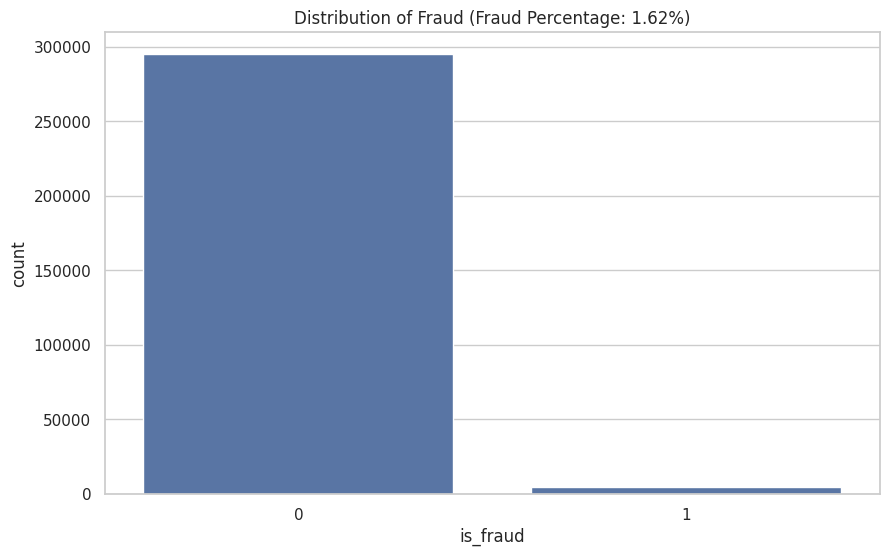

Total Transactions: 300113
Fraud Cases: 4871
Non-Fraud Cases: 295242


In [ ]:
fraud_counts = train_df['is_fraud'].value_counts()
fraud_pct = train_df['is_fraud'].mean() * 100

sns.countplot(x='is_fraud', data=train_df)
plt.title(f'Distribution of Fraud (Fraud Percentage: {fraud_pct:.2f}%)')
plt.show()

print(f"Total Transactions: {len(train_df)}")
print(f"Fraud Cases: {fraud_counts[1]}")
print(f"Non-Fraud Cases: {fraud_counts[0]}")

### Interpretation
The dataset exhibits extreme class imbalance. Models trained on this data might default to predicting 'Non-Fraud' for every case. We must ensure our preprocessing and modeling strategies account for this rarity.

## 4. Univariate Analysis (Numerical Features)
We examine the distribution of numerical features to identify skewness and outliers, which are common in transaction data (e.g., transaction amounts).

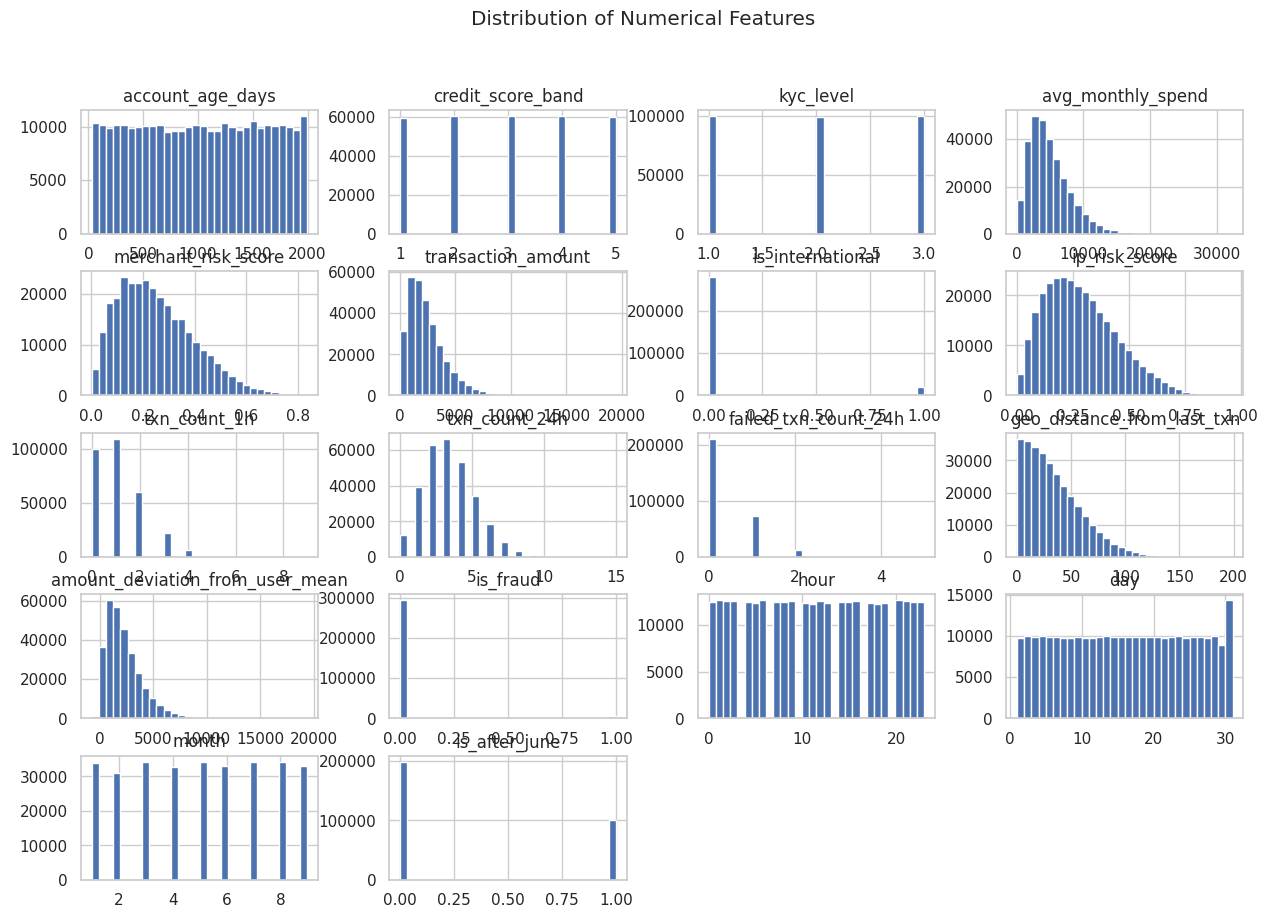

In [ ]:
num_features = train_df.select_dtypes(include=[np.number]).columns

train_df[num_features].hist(bins=30, figsize=(15, 10))
plt.suptitle('Distribution of Numerical Features')
plt.show()

## 5. Bivariate Analysis (Fraud vs Features)
By comparing features against the target `is_fraud`, we can identify which variables are the strongest indicators of criminal activity.

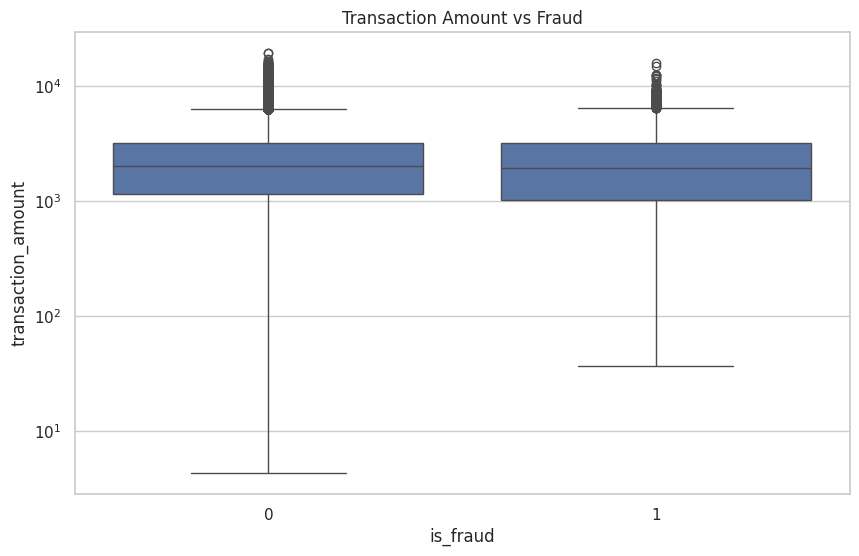

In [ ]:
# Relationship between Transaction Amount and Fraud
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_fraud', y='transaction_amount', data=train_df)
plt.title('Transaction Amount vs Fraud')
plt.yscale('log') # Log scale for better visibility of outliers
plt.show()

## 6. Categorical Feature Analysis
We examine categorical variables to identify which channels or devices are most frequently associated with fraudulent activity.

Found payment columns: ['payment_channel_card', 'payment_channel_upi', 'payment_channel_wallet']
Found device columns: ['device_type_mobile', 'device_type_tablet']


/tmp/ipykernel_8970/412267884.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(fraud_rates_payment.keys()), y=list(fraud_rates_payment.values()), palette='magma')
/tmp/ipykernel_8970/412267884.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(fraud_rates_device.keys()), y=list(fraud_rates_device.values()), palette='viridis')


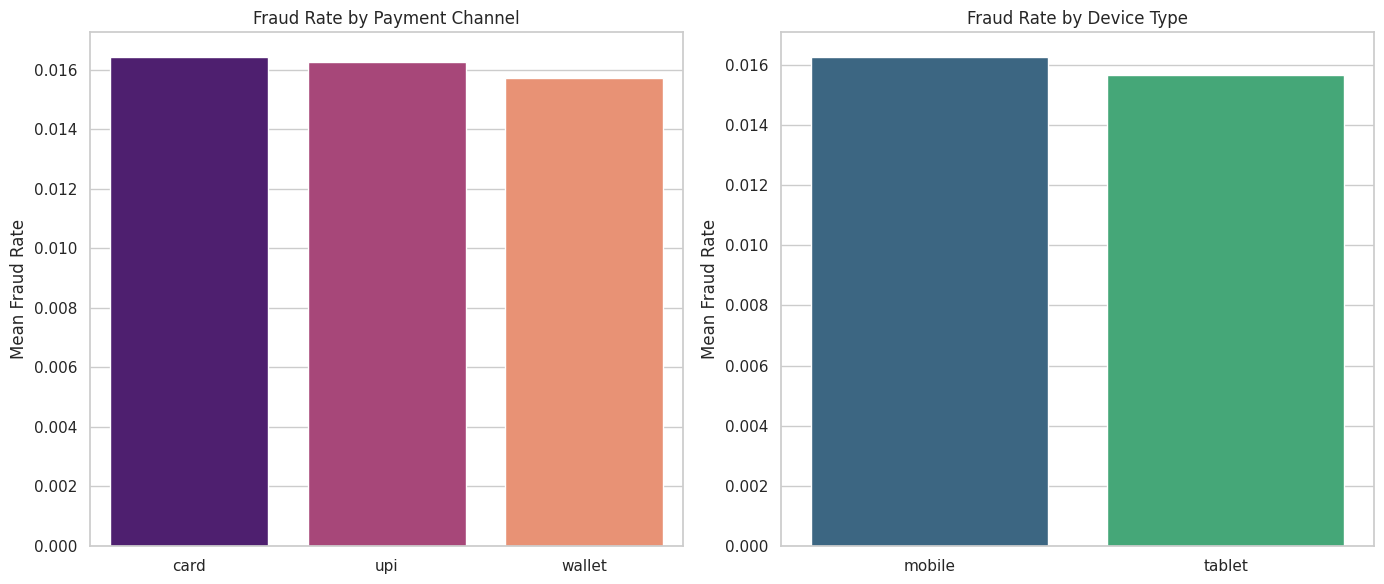

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check for one-hot encoded versions of the categorical columns
payment_cols = [col for col in train_df.columns if 'payment_channel' in col]
device_cols = [col for col in train_df.columns if 'device_type' in col]

print(f"Found payment columns: {payment_cols}")
print(f"Found device columns: {device_cols}")

# If they are encoded, we can visualize fraud rates by averaging the binary flags
if payment_cols or device_cols:
    plt.figure(figsize=(14, 6))

    # Plotting Fraud Rate by Payment Channel
    if payment_cols:
        plt.subplot(1, 2, 1)
        fraud_rates_payment = {col.split('_')[-1]: train_df[train_df[col] > 0]['is_fraud'].mean() for col in payment_cols}
        sns.barplot(x=list(fraud_rates_payment.keys()), y=list(fraud_rates_payment.values()), palette='magma')
        plt.title('Fraud Rate by Payment Channel')
        plt.ylabel('Mean Fraud Rate')

    # Plotting Fraud Rate by Device Type
    if device_cols:
        plt.subplot(1, 2, 2)
        fraud_rates_device = {col.split('_')[-1]: train_df[train_df[col] > 0]['is_fraud'].mean() for col in device_cols}
        sns.barplot(x=list(fraud_rates_device.keys()), y=list(fraud_rates_device.values()), palette='viridis')
        plt.title('Fraud Rate by Device Type')
        plt.ylabel('Mean Fraud Rate')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical or encoded columns found for analysis.")

### Identifying Risky Categories
Based on the plots above, we can identify specific values that have a significantly higher 'Mean Fraud Rate' than the baseline. These are our high-risk segments which will be critical features for the classification model.

## 7. Correlation Analysis
A heatmap helps us understand the linear relationships between features and identify redundancy.

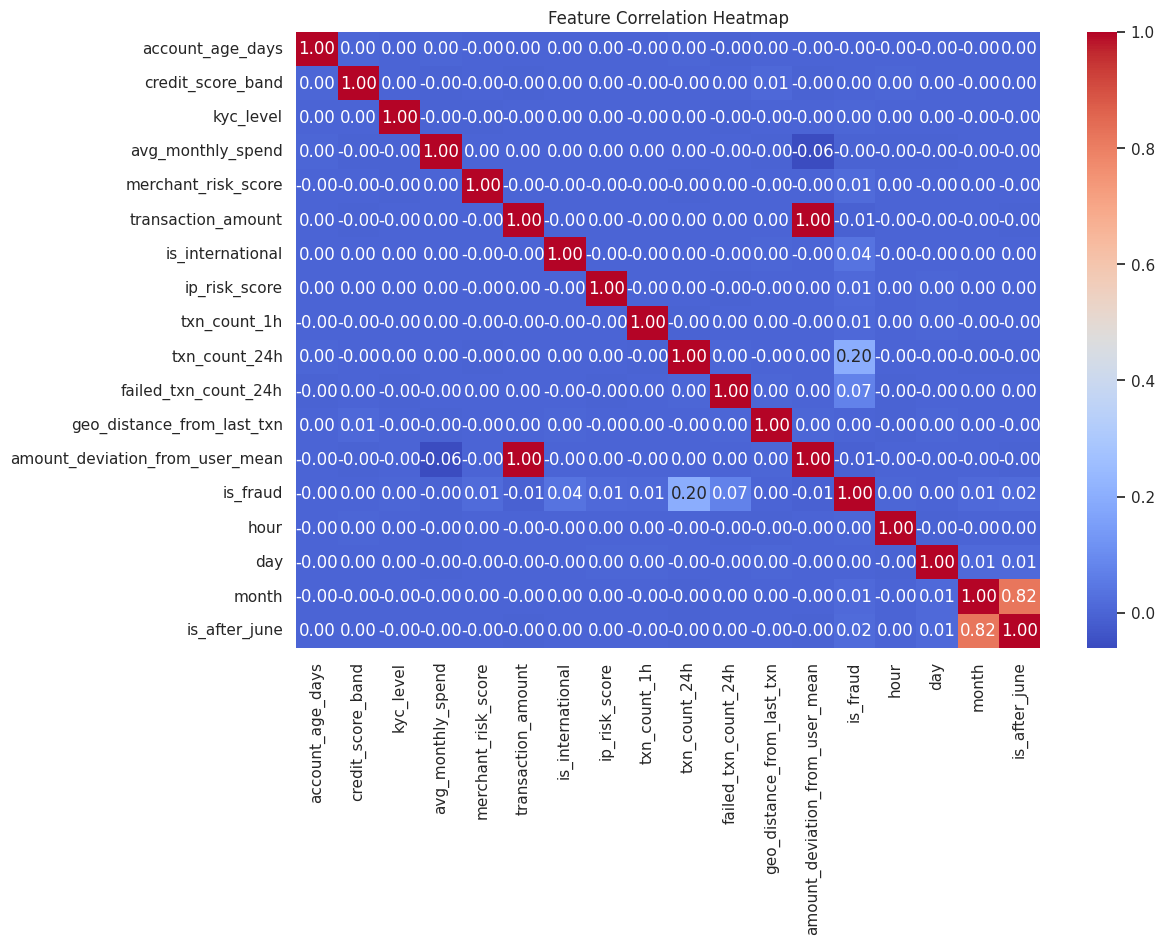

In [ ]:
plt.figure(figsize=(12, 8))
corr_matrix = train_df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

## 8. Concept Drift Analysis
Fraudsters change their tactics over time. We will compare the first half of the year (Jan-Jun) with the second half (Jul-Dec) to observe shifts in behavior.

/tmp/ipykernel_8970/3046461818.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=period_fraud.index, y=period_fraud.values, palette='coolwarm')
/tmp/ipykernel_8970/3046461818.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='period', palette='coolwarm')


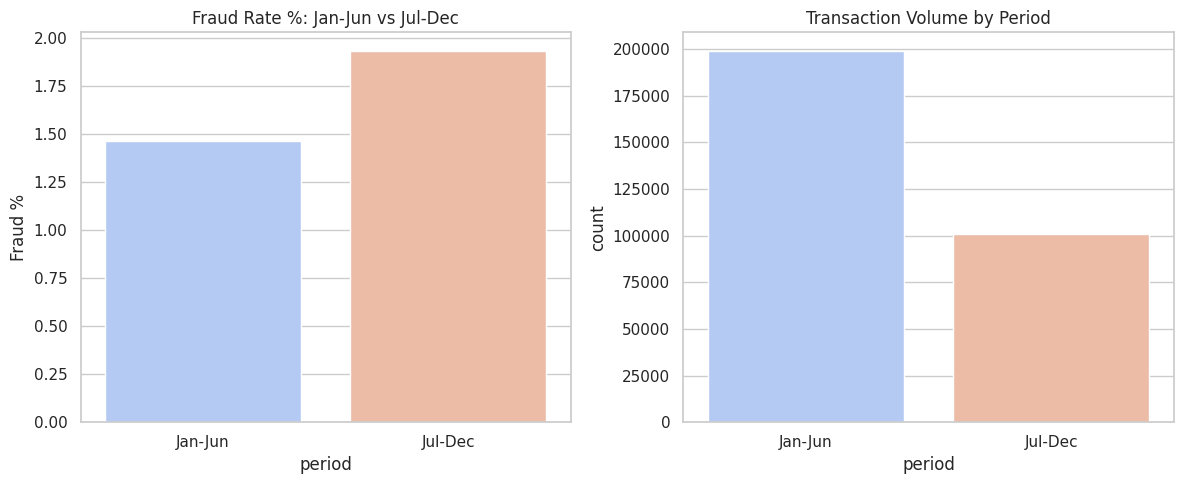

Fraud Rate (Jan-Jun): 1.46%
Fraud Rate (Jul-Dec): 1.94%


In [ ]:
# 8. Concept Drift Analysis: Comparing Time Periods

# 1. Create Period Feature
train_df['period'] = train_df['transaction_time'].dt.month.map(
    lambda x: 'Jan-Jun' if x <= 6 else 'Jul-Dec'
)

# 2. Fraud Rate Comparison
period_fraud = train_df.groupby('period')['is_fraud'].mean() * 100

plt.figure(figsize=(12, 5))

# Plot A: Fraud Rate by Period
plt.subplot(1, 2, 1)
sns.barplot(x=period_fraud.index, y=period_fraud.values, palette='coolwarm')
plt.title('Fraud Rate %: Jan-Jun vs Jul-Dec')
plt.ylabel('Fraud %')

# Plot B: Transaction Count by Period
plt.subplot(1, 2, 2)
sns.countplot(data=train_df, x='period', palette='coolwarm')
plt.title('Transaction Volume by Period')

plt.tight_layout()
plt.show()

print(f"Fraud Rate (Jan-Jun): {period_fraud['Jan-Jun']:.2f}%")
print(f"Fraud Rate (Jul-Dec): {period_fraud['Jul-Dec']:.2f}%")

## 9. Time-Based Analysis
Fraud often follows temporal patterns (e.g., higher activity at night or during holidays).

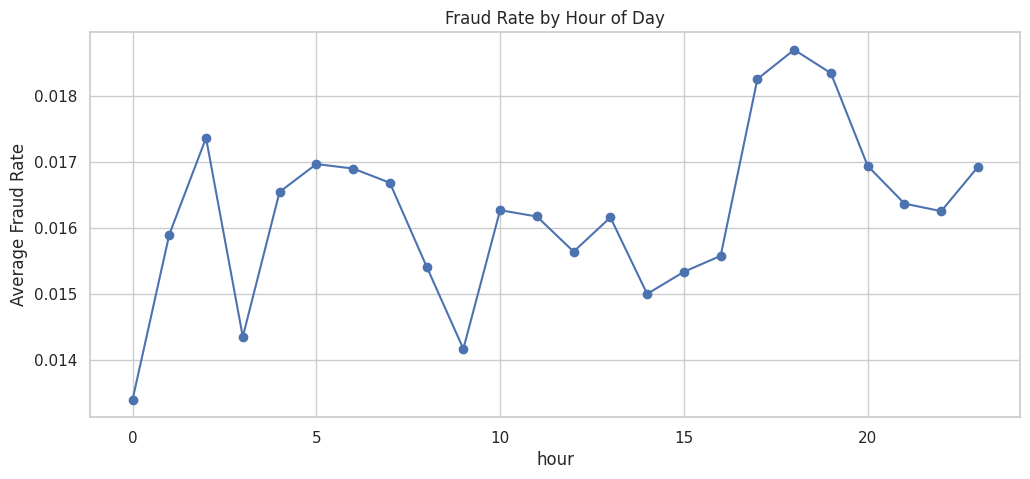

In [ ]:
train_df['hour'] = train_df['transaction_time'].dt.hour
hourly_fraud = train_df.groupby('hour')['is_fraud'].mean()

plt.figure(figsize=(12, 5))
hourly_fraud.plot(kind='line', marker='o')
plt.title('Fraud Rate by Hour of Day')
plt.ylabel('Average Fraud Rate')
plt.grid(True)
plt.show()

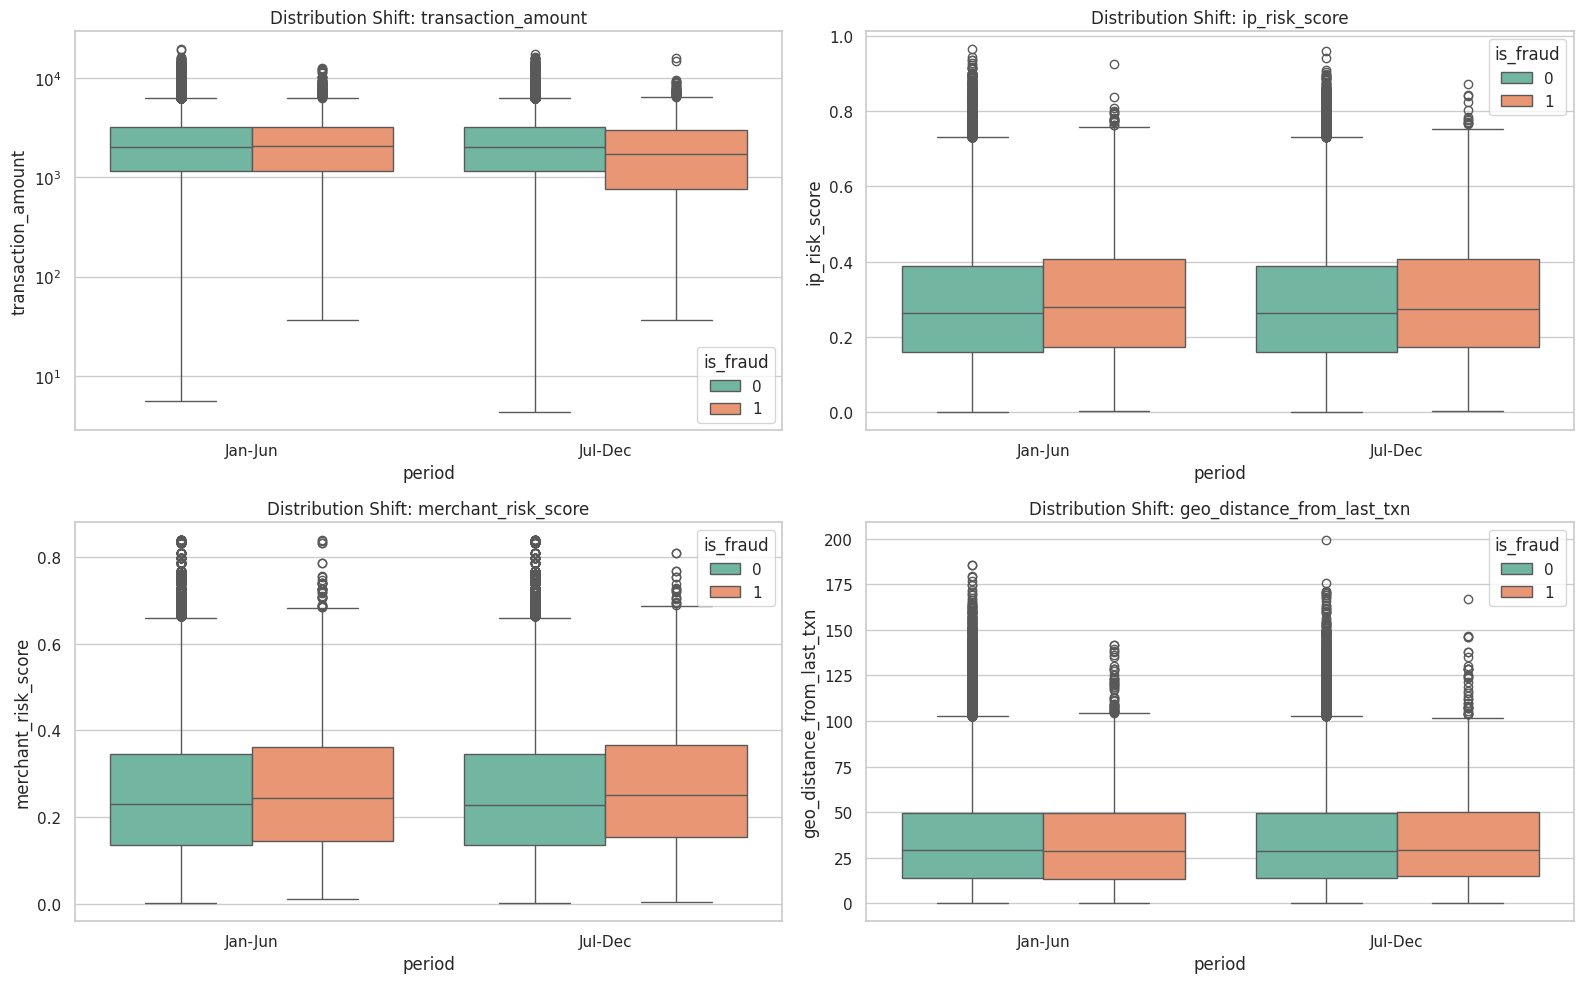

Mean Feature Values by Period:


transaction_amount  ip_risk_score  merchant_risk_score  \
period  is_fraud                                                           
Jan-Jun 0                2404.670379       0.285240             0.251287   
        1                2417.136360       0.302253             0.267501   
Jul-Dec 0                2401.698667       0.285809             0.250815   
        1                2146.178564       0.301353             0.269735   

                  geo_distance_from_last_txn  
period  is_fraud                              
Jan-Jun 0                          34.200103  
        1                          34.181829  
Jul-Dec 0                          34.121776  
        1                          35.191955

In [ ]:
# 3. Feature Distribution Shift (Boxplots)
drift_features = ['transaction_amount', 'ip_risk_score', 'merchant_risk_score', 'geo_distance_from_last_txn']

plt.figure(figsize=(16, 10))
for i, col in enumerate(drift_features):
    plt.subplot(2, 2, i+1)
    sns.boxplot(data=train_df, x='period', y=col, hue='is_fraud', palette='Set2')
    plt.title(f'Distribution Shift: {col}')
    if col == 'transaction_amount':
        plt.yscale('log')

plt.tight_layout()
plt.show()

# Calculate Mean differences
print("Mean Feature Values by Period:")
display(train_df.groupby(['period', 'is_fraud'])[drift_features].mean())

### Interpreting Concept Drift
- **Fraud Rate Shift:** The rise in fraud percentage indicates that the environment is becoming riskier or fraudsters are finding new loopholes.
- **Distributional Drift:** If we see the boxplots shifting (e.g., higher transaction amounts or higher risk scores for 'Non-Fraud' cases in the second period), it means the model's decision boundary must adapt.
- **SDG 16 Impact:** Continuous monitoring of these shifts is vital for maintaining the 'effective, accountable, and transparent' financial institutions promised by SDG 16.

## 10. Feature Importance Insight
By training a quick Random Forest model, we can rank the features by their predictive power. This helps validate our EDA findings and confirms if the time-based features we reconstructed are useful.

/tmp/ipykernel_8970/2435448633.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x='importance', y='feature', palette='magma')


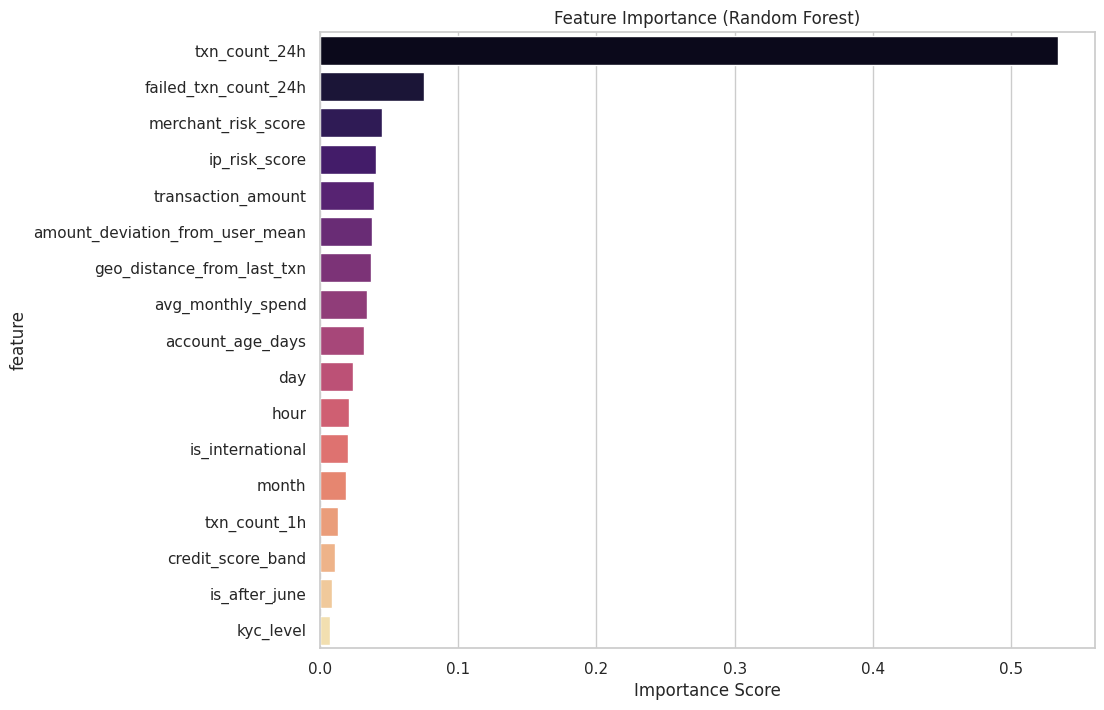

,feature,importance
9,txn_count_24h,0.533593
10,failed_txn_count_24h,0.075110
4,merchant_risk_score,0.044727
7,ip_risk_score,0.040608
5,transaction_amount,0.038956
12,amount_deviation_from_user_mean,0.038119
11,geo_distance_from_last_txn,0.037082
3,avg_monthly_spend,0.034450
0,account_age_days,0.032133
14,day,0.024028


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Prepare data for a quick importance check
# We exclude non-numeric or high-cardinality targets like 'transaction_time' and 'period'
X = train_df.select_dtypes(include=[np.number]).drop(columns=['is_fraud'])
y = train_df['is_fraud']

# Initialize and fit Random Forest
rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X, y)

# Get feature importance
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

# Visualization
plt.figure(figsize=(10, 8))
sns.barplot(data=importances, x='importance', y='feature', palette='magma')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.show()

display(importances.head(10))

### Analysis of Concept Drift
If the fraud rate or feature distributions (e.g., transaction amounts) differ significantly between these two periods, it confirms **Concept Drift**. This suggests that a model trained only on early data may fail as the year progresses. This volatility weakens institutional trust, highlighting the need for adaptive systems as advocated by SDG 16.

## 11. Final Preprocessing: Scaling
Standardizing numerical features ensures that features with larger magnitudes do not dominate the model's learning process.

In [ ]:
scaler = StandardScaler()
num_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
if 'is_fraud' in num_cols: num_cols.remove('is_fraud')

# Apply scaling to Train and Test to maintain consistency
train_df[num_cols] = scaler.fit_transform(train_df[num_cols])
test_df[num_cols] = scaler.transform(test_df[num_cols])

print("Numerical features scaled successfully.")
display(train_df[num_cols].head())

Numerical features scaled successfully.


,account_age_days,credit_score_band,kyc_level,avg_monthly_spend,merchant_risk_score,transaction_amount,is_international,ip_risk_score,txn_count_1h,txn_count_24h,failed_txn_count_24h,geo_distance_from_last_txn,amount_deviation_from_user_mean,hour,day,month,is_after_june
0,-1.281751,-0.711466,1.223454,0.351381,1.397822,0.003646,-0.272558,-0.893831,-0.095696,-0.112850,1.096306,-0.028110,-0.018016,-1.658206,-1.67277,-1.558508,-0.712847
1,0.604563,-0.711466,1.223454,-0.378604,1.348366,0.213687,-0.272558,-0.960766,-1.049831,1.005289,-0.591768,-1.198545,0.236635,-1.658206,-1.67277,-1.558508,-0.712847
2,0.525894,1.416535,0.000705,0.543689,-0.212593,-0.513748,-0.272558,0.227498,-1.049831,1.005289,-0.591768,-0.795565,-0.546331,-1.658206,-1.67277,-1.558508,-0.712847
3,1.567825,-1.420799,-1.222045,-0.660511,-0.335610,-1.054346,-0.272558,-0.711327,-0.095696,-0.671920,-0.591768,-0.596845,-1.011741,-1.658206,-1.67277,-1.558508,-0.712847
4,-1.148888,-0.711466,1.223454,0.030789,-0.547084,-0.833093,-0.272558,-0.230580,-0.095696,-1.230990,-0.591768,-0.732856,-0.833490,-1.658206,-1.67277,-1.558508,-0.712847
